In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error 
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [13]:
ticker = "COALINDIA.NS"

data = yf.download(ticker, period="1y", interval="1d")
data=data[['Close']]
data=data.dropna()
print("Download Data:")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Download Data:
Price             Close
Ticker     COALINDIA.NS
Date                   
2025-03-03   336.679749
2025-03-04   339.949860
2025-03-05   344.060822
2025-03-06   357.468231
2025-03-07   355.646301


In [14]:
data['Next_Close']= data['Close'].shift(-1)
data= data.dropna()

In [15]:
X = data[['Close']]
Y = data['Next_Close']

In [16]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

Y_train = Y.iloc[:split_index]
Y_test = Y.iloc[split_index:]

print(f"/nTraining rows: {len(X_train)}")
print(f"Testing rows : {len(X_test)}")

/nTraining rows: 197
Testing rows : 50


In [19]:
model = LinearRegression()
model.fit(X_train, Y_train)

print("\nModel Parameters:")
print("Intercept (β0):",model.intercept_)
print("Slope     (β1):", model.coef_[0])


Model Parameters:
Intercept (β0): 47.55940541029332
Slope     (β1): 0.871405855666593


In [20]:
Y_pred = model.predict(X_test)

In [21]:
print("\nmodel Performance:")
print("R-squared:", r2_score(Y_test, Y_pred))
print("Mean Squared Error:", mean_squared_error(Y_test, Y_pred))


model Performance:
R-squared: 0.49961738362384966
Mean Squared Error: 106.03305783787546


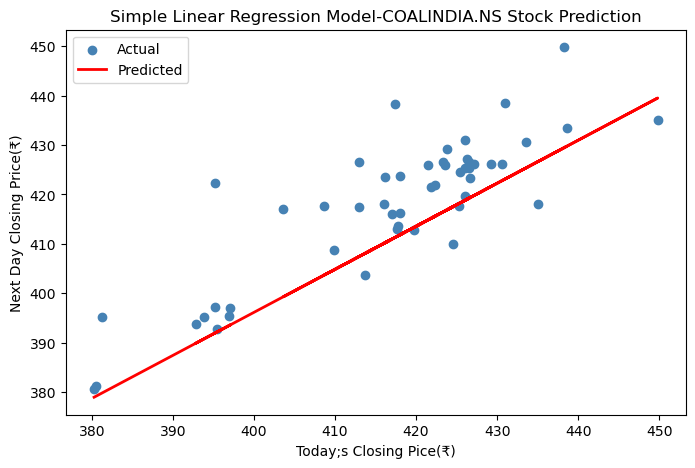

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, Y_test, label='Actual',color='steelblue')
plt.plot(X_test, Y_pred, label='Predicted',color='red',linewidth=2)
plt.xlabel("Today;s Closing Pice(₹)")
plt.ylabel("Next Day Closing Price(₹)")
plt.title("Simple Linear Regression Model-COALINDIA.NS Stock Prediction")
plt.legend()
plt.show()

In [24]:
residual = Y_test - Y_pred

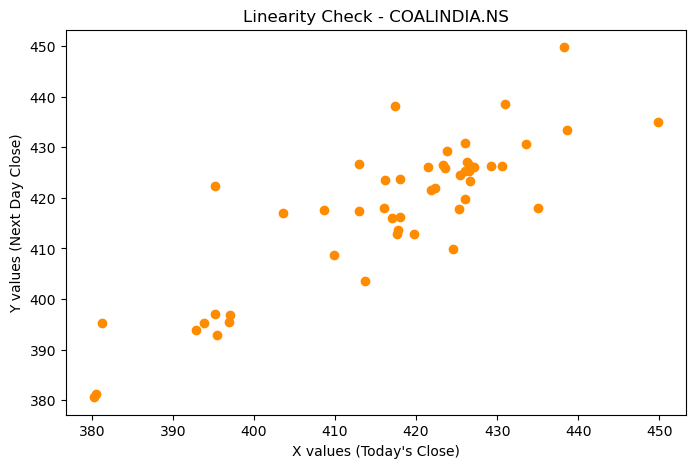

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, Y_test, color = 'darkorange')
plt.xlabel("X values (Today's Close)")
plt.ylabel("Y values (Next Day Close)")
plt.title("Linearity Check - COALINDIA.NS")
plt.show()


Normality Test (Shapiro-Wilk):
ShapiroResult(statistic=0.9495279288628287, pvalue=0.0326261209351955)


<Figure size 800x500 with 0 Axes>

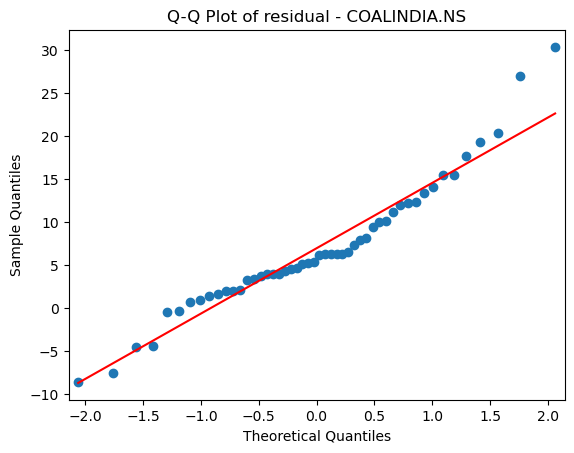

In [26]:
print("\nNormality Test (Shapiro-Wilk):")
print(stats.shapiro(residual))
plt.figure(figsize=(8, 5))
sm.qqplot(residual, line='s')
plt.title("Q-Q Plot of residual - COALINDIA.NS")
plt.show()

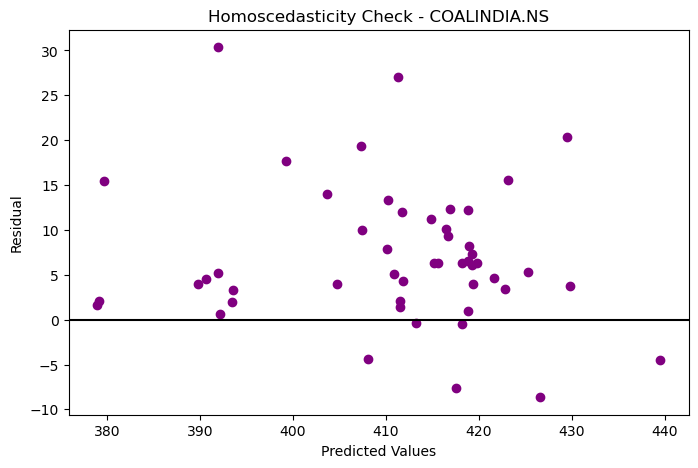

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(Y_pred, residual, color='purple')
plt.axhline(y=0, color='black', linewidth=1.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residual")
plt.title("Homoscedasticity Check - COALINDIA.NS")
plt.show()

In [28]:
dw_stat = durbin_watson(residual)
print("\nDurbin-Watson Statistic:", dw_stat)


Durbin-Watson Statistic: 1.039895913255641


In [30]:
last_close_value = float(data['Close'].iloc[-1].iloc[0])
last_closing_price = np.array([[last_close_value]])
next_day_prediction = model.predict(last_closing_price)
print("\nLast Closing Price of COALINDIA.NS : ₹", round(last_close_value, 2))
print("Predicted Next Day Closing Price: ₹", round(float(next_day_prediction[0]), 2))


Last Closing Price of COALINDIA.NS : ₹ 430.65
Predicted Next Day Closing Price: ₹ 422.83
